# Bayesian Goal Inference in Overcooked-AI: From Symbolic Actions to Vision

**CS6208 Advanced Topics in AI — Tutorial Notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ceilingFan456/CS6208_AY25-26_project/blob/main/colab/tutorial_bayesian_goal_inference.ipynb)

---

## Learning Outcomes

By the end of this notebook, you will be able to:

1. **Understand Bayesian goal inference** — how to maintain and update a belief distribution over candidate goals using sequential observations.
2. **Implement plan-based action likelihoods** — model how a goal-directed agent selects actions from a partially-ordered plan with noise.
3. **Extend to multi-step cooking domains** — apply the same framework to Overcooked-AI recipes involving pick-up, cook, and serve sequences.
4. **Use CLIP for vision-based inference** — replace ground-truth action labels with a vision model that classifies actions from raw game frames, and marginalize over actions to compute goal likelihoods.
5. **Use a Vision Language Model (Qwen3-VL)** — directly estimate goal posteriors from game frames end-to-end.
6. **Analyze the effect of classifier accuracy** — understand how the quality of the visual action classifier affects inference convergence.
7. **Compare symbolic, CLIP, VLM, and dummy-CLIP approaches** — evaluate trade-offs between different observation modalities for Bayesian goal inference.

## Overview

We implement a miniature version of **CLIPS** (Cooperative Language-Guided Inverse Plan Search), a Bayesian framework for inferring an agent's goal from observed behavior. The core idea is simple:

$$P(g \mid \text{obs}_{1:t}) \propto P(\text{obs}_t \mid g) \cdot P(g \mid \text{obs}_{1:t-1})$$

We progressively build up from the simplest setting (observing ground-truth actions) to vision-based inference (observing raw game frames), comparing four likelihood models:

| Method | Input | Approach |
|--------|-------|----------|
| **Symbolic** | Ground-truth actions | Plan-based likelihood with noise |
| **CLIP** | Raw game frames | Action classification → marginalization |
| **Qwen3-VL** | Raw game frames | VLM directly estimates goal posteriors |
| **Dummy CLIP** | Simulated classifier | Ideal classifier to study upper bounds |

## Table of Contents

1. [Setup](#setup)
2. [Bayesian Inference Foundations](#bayesian)
3. [Goal & Plan Model (Grocery Shopping)](#goals)
4. [Symbolic Action Inference](#symbolic)
5. [Overcooked-AI: Multi-Step Recipes](#overcooked)
6. [CLIP Vision-Based Inference](#clip)
7. [Qwen3-VL: Direct VLM Inference](#qwen)
8. [Effect of Classifier Accuracy](#dummy-clip)
9. [Summary & Extensions](#summary)

**Estimated reading time:** ~60 minutes (including running all cells)

---

## 1. Setup <a name="setup"></a>

First, we install the required packages. This cell only needs to run once per Colab session.

In [ ]:
# === Install dependencies (run once) ===
!pip install -q "numpy<2" matplotlib Pillow scipy tqdm ipywidgets

# ML dependencies for CLIP and Qwen3-VL
!pip install -q torch torchvision transformers qwen-vl-utils

# Install our modified Overcooked-AI fork (adds 10 custom ingredients + layouts)
!pip install -q pygame
!git clone --depth 1 https://github.com/ceilingFan456/overcooked_ai.git /tmp/overcooked_ai 2>/dev/null || true
!pip install -q -e /tmp/overcooked_ai

print("All dependencies installed!")

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from dataclasses import dataclass, field
from typing import Dict, List, Set, Optional, Tuple, Callable
from collections import Counter
from IPython.display import display, Markdown

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# Color palette for plots
COLORS = ['#4CAF50', '#FF9800', '#2196F3', '#F44336', '#9C27B0', '#00BCD4']

# Output directory for saved figures
FIGURES_DIR = 'tutorial_figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

print("Imports ready.")

Imports ready.


---

## 2. Bayesian Inference Foundations <a name="bayesian"></a>

The backbone of our system is **recursive Bayesian updating**. At each time step $t$, we receive an observation $\text{obs}_t$ and update our belief (posterior) over candidate goals:

$$P(g \mid \text{obs}_{1:t}) = \frac{P(\text{obs}_t \mid g) \cdot P(g \mid \text{obs}_{1:t-1})}{\sum_{g'} P(\text{obs}_t \mid g') \cdot P(g' \mid \text{obs}_{1:t-1})}$$

Where:
- $P(g \mid \text{obs}_{1:t-1})$ is the **prior** (our belief before the new observation)
- $P(\text{obs}_t \mid g)$ is the **likelihood** (how probable is this observation if goal $g$ is true?)
- The denominator normalizes so probabilities sum to 1

This is just Bayes' rule applied recursively. The key challenge is computing the likelihood — and that's where the different methods (symbolic, CLIP, VLM) come in.

Let's implement these two building blocks:

In [2]:
def normalize(probs: np.ndarray) -> np.ndarray:
    """Normalize a probability vector to sum to 1."""
    total = float(np.sum(probs))
    if total <= 0.0:
        raise ValueError(f"Cannot normalize: probability mass is zero")
    return probs / total


def posterior_update(prior: np.ndarray, likelihood: np.ndarray) -> np.ndarray:
    """Bayesian posterior update: posterior(g) ∝ likelihood(obs|g) * prior(g)."""
    unnormalized = prior * likelihood
    return normalize(unnormalized)


# Quick demonstration
prior = np.array([0.25, 0.25, 0.25, 0.25])  # uniform over 4 goals
likelihood = np.array([0.5, 0.1, 0.3, 0.1])  # obs is most likely under goal 0

posterior = posterior_update(prior, likelihood)
print(f"Prior:      {prior}")
print(f"Likelihood: {likelihood}")
print(f"Posterior:  {np.round(posterior, 3)}")
print(f"Sum:        {posterior.sum():.6f}  (should be 1.0)")

Prior:      [0.25 0.25 0.25 0.25]
Likelihood: [0.5 0.1 0.3 0.1]
Posterior:  [0.5 0.1 0.3 0.1]
Sum:        1.000000  (should be 1.0)


Notice how the posterior shifts toward goal 0, which had the highest likelihood. The uniform prior didn't favor any goal, so the posterior is entirely driven by the likelihood.

**Key insight:** After the first update, the posterior becomes the new prior for the next observation. This is how evidence accumulates over time — each observation sharpens the belief.

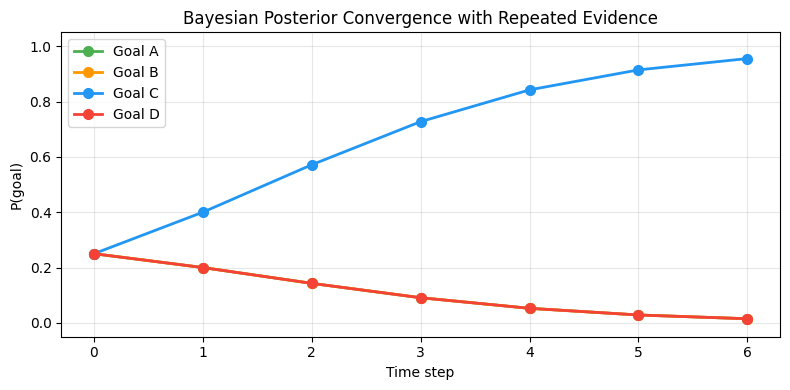

In [3]:
# Let's visualize how repeated observations sharpen beliefs
goals = ['Goal A', 'Goal B', 'Goal C', 'Goal D']
prior = np.array([0.25, 0.25, 0.25, 0.25])

# Suppose each observation is slightly more consistent with Goal C
likelihood_per_step = np.array([0.2, 0.2, 0.4, 0.2])

trajectory = [prior.copy()]
current = prior.copy()
for step in range(6):
    current = posterior_update(current, likelihood_per_step)
    trajectory.append(current.copy())

fig, ax = plt.subplots(figsize=(8, 4))
for i, g in enumerate(goals):
    ax.plot(range(len(trajectory)), [t[i] for t in trajectory],
            'o-', color=COLORS[i], linewidth=2, label=g, markersize=7)
ax.set_xlabel('Time step'); ax.set_ylabel('P(goal)')
ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Bayesian Posterior Convergence with Repeated Evidence')
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'bayesian_convergence.png'), dpi=150, bbox_inches='tight')
plt.show()

Even though each individual observation only weakly favors Goal C (probability 0.4 vs 0.2 for others), after just a few steps the posterior strongly concentrates on it. This is the power of sequential Bayesian updating.

---

## 3. Goal & Plan Model (Grocery Shopping) <a name="goals"></a>

Now let's define a concrete domain. Imagine a grocery store where a shopper is collecting ingredients for one of four possible recipes. Each recipe has a **partially-ordered plan** — a DAG (directed acyclic graph) of actions with dependency constraints.

For example, to make fried rice you need rice, onion, soy sauce, frozen peas, and frozen carrots. The frozen items can only be picked up *after* all non-frozen items (they'd melt otherwise!).

### The Plans

```
Greek Salad:    tomato, olives, cucumber, onion, feta_cheese → checkout
Veggie Burger:  hamburger_bun, tomato, onion, lettuce → frozen_patty → checkout
Fried Rice:     rice, onion, soy_sauce → frozen_peas, frozen_carrots → checkout
Burrito Bowl:   rice, black_beans, cotija_cheese, onion, tomato → checkout
```

Arrows (→) indicate dependency constraints. Items before the arrow must be collected before items after it.

In [4]:
# Define the four candidate goals (recipes)
GOALS = ["greek_salad", "veggie_burger", "fried_rice", "burrito_bowl"]

# Plans: each action maps to its list of dependencies
PLANS: Dict[str, Dict[str, List[str]]] = {
    "greek_salad": {
        "get(tomato)": [],
        "get(olives)": [],
        "get(cucumber)": [],
        "get(onion)": [],
        "get(feta_cheese)": [],
        "checkout()": ["get(tomato)", "get(olives)", "get(cucumber)",
                       "get(onion)", "get(feta_cheese)"],
    },
    "veggie_burger": {
        "get(hamburger_bun)": [],
        "get(tomato)": [],
        "get(onion)": [],
        "get(lettuce)": [],
        "get(frozen_patty)": ["get(hamburger_bun)", "get(tomato)",
                              "get(onion)", "get(lettuce)"],
        "checkout()": ["get(hamburger_bun)", "get(tomato)", "get(onion)",
                       "get(lettuce)", "get(frozen_patty)"],
    },
    "fried_rice": {
        "get(rice)": [],
        "get(onion)": [],
        "get(soy_sauce)": [],
        "get(frozen_peas)": ["get(rice)", "get(onion)", "get(soy_sauce)"],
        "get(frozen_carrots)": ["get(rice)", "get(onion)", "get(soy_sauce)"],
        "checkout()": ["get(rice)", "get(onion)", "get(soy_sauce)",
                       "get(frozen_peas)", "get(frozen_carrots)"],
    },
    "burrito_bowl": {
        "get(rice)": [],
        "get(black_beans)": [],
        "get(cotija_cheese)": [],
        "get(onion)": [],
        "get(tomato)": [],
        "checkout()": ["get(rice)", "get(black_beans)", "get(cotija_cheese)",
                       "get(onion)", "get(tomato)"],
    },
}

# Full action space (union of all plan actions + wait)
ACTIONS = sorted({act for plan in PLANS.values() for act in plan.keys()})
ACTIONS.append("wait()")

# Uniform prior
PRIOR = np.full(len(GOALS), 1.0 / len(GOALS))

print(f"Goals: {GOALS}")
print(f"Total unique actions: {len(ACTIONS)}")
print(f"Actions: {ACTIONS}")

Goals: ['greek_salad', 'veggie_burger', 'fried_rice', 'burrito_bowl']
Total unique actions: 16
Actions: ['checkout()', 'get(black_beans)', 'get(cotija_cheese)', 'get(cucumber)', 'get(feta_cheese)', 'get(frozen_carrots)', 'get(frozen_patty)', 'get(frozen_peas)', 'get(hamburger_bun)', 'get(lettuce)', 'get(olives)', 'get(onion)', 'get(rice)', 'get(soy_sauce)', 'get(tomato)', 'wait()']


---

## 4. Symbolic Action Inference <a name="symbolic"></a>

Now we build the **likelihood function** — the probability of observing an action given a goal and the current state.

### Action Likelihood Model

Given goal $g$ with plan $\pi$ at state $s$ (set of completed actions):

1. **Planned actions**: Actions whose dependencies are all satisfied and that haven't been done yet
2. The agent follows its plan with probability $(1 - \varepsilon)$, choosing uniformly among planned actions
3. With probability $\varepsilon$ (noise), the agent takes a random action from all possible actions

$$P(a_t \mid g, s_{t-1}) = \begin{cases}
\frac{1-\varepsilon}{|\text{planned}|} + \frac{\varepsilon}{|\text{possible}|} & \text{if } a_t \text{ is planned} \\
\frac{\varepsilon}{|\text{possible}|} & \text{otherwise}
\end{cases}$$

The noise term $\varepsilon$ is crucial — without it, observing an "off-plan" action would give zero likelihood, and Bayes' rule would permanently eliminate that goal.

In [6]:
def get_planned_actions(state: Set[str], plan: Dict[str, List[str]]) -> List[str]:
    """Return actions from the plan that are currently executable.

    An action is planned if:
    - It hasn't been completed yet (not in state)
    - All its dependencies have been completed (are in state)
    """
    planned = []
    for act, deps in plan.items():
        if act in state:
            continue  # already done
        if all(dep in state for dep in deps):
            planned.append(act)  # all dependencies met
    return sorted(planned) if planned else ["wait()"]


def action_likelihood(
    observed_action: str,
    state: Set[str],
    plan: Dict[str, List[str]],
    act_noise: float = 0.05,
    action_space: List[str] = ACTIONS,
) -> float:
    """Compute P(observed_action | goal, state) using the plan model."""
    planned_acts = get_planned_actions(state, plan)
    possible_acts = [a for a in action_space if a not in state]

    p = 0.0
    # Planned component: (1 - noise) / |planned|
    if observed_action in planned_acts:
        p += (1.0 - act_noise) / len(planned_acts)
    # Noise component: noise / |possible|
    if observed_action in possible_acts:
        p += act_noise / len(possible_acts)
    return p


# Example: at the start, what's the likelihood of get(rice) for each goal?
empty_state = set()
print("P(get(rice) | goal, empty state):")
for goal in GOALS:
    p = action_likelihood("get(rice)", empty_state, PLANS[goal])
    planned = get_planned_actions(empty_state, PLANS[goal])
    print(f"  {goal:15s}: {p:.4f}  (planned: {planned})")

P(get(rice) | goal, empty state):
  greek_salad    : 0.0031  (planned: ['get(cucumber)', 'get(feta_cheese)', 'get(olives)', 'get(onion)', 'get(tomato)'])
  veggie_burger  : 0.0031  (planned: ['get(hamburger_bun)', 'get(lettuce)', 'get(onion)', 'get(tomato)'])
  fried_rice     : 0.3198  (planned: ['get(onion)', 'get(rice)', 'get(soy_sauce)'])
  burrito_bowl   : 0.1931  (planned: ['get(black_beans)', 'get(cotija_cheese)', 'get(onion)', 'get(rice)', 'get(tomato)'])


Notice that `get(rice)` is a **planned** action for `fried_rice` and `burrito_bowl`, so it gets high probability. For `greek_salad` and `veggie_burger`, it can only occur through noise, giving it very low probability. This asymmetry is what drives the Bayesian inference.

### Running the Full Inference Loop

Now let's simulate a shopper collecting ingredients for fried rice and watch the posterior evolve:

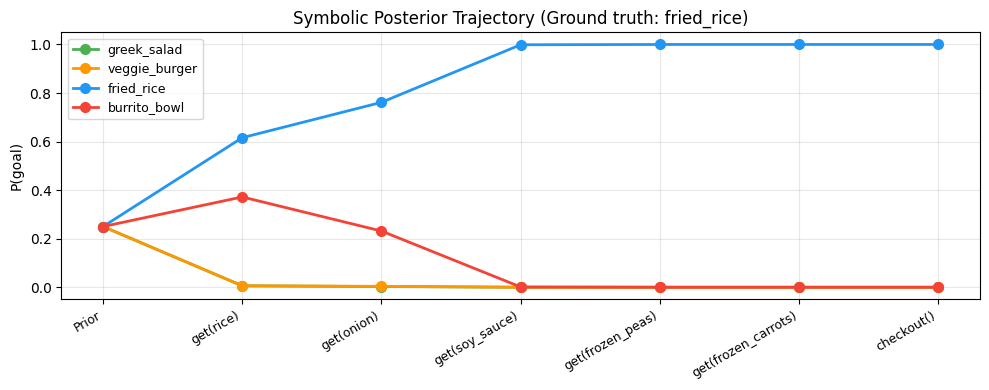

Final posterior: {'greek_salad': 0.0, 'veggie_burger': 0.0, 'fried_rice': 1.0, 'burrito_bowl': 0.0}


In [7]:
@dataclass(frozen=True)
class Observation:
    """A symbolic observation at one timestep."""
    kind: str   # 'act' or 'utterance'
    value: str  # e.g. 'get(rice)'


def run_inference_loop(
    observations: List[Observation],
    goals: List[str] = GOALS,
    plans: Dict[str, Dict[str, List[str]]] = PLANS,
    prior: np.ndarray = PRIOR,
    act_noise: float = 0.05,
) -> Dict:
    """Run sequential Bayesian goal inference over a list of observations."""
    posterior = prior.copy()
    states = {goal: set() for goal in goals}  # per-goal completed actions
    posterior_trajectory = [posterior.copy()]

    for obs in observations:
        likelihood = np.zeros(len(goals))
        for i, goal in enumerate(goals):
            likelihood[i] = action_likelihood(
                obs.value, states[goal], plans[goal], act_noise
            )
        posterior = posterior_update(posterior, likelihood)
        posterior_trajectory.append(posterior.copy())

        # Update state: all goals track the action as completed
        if obs.kind == 'act' and obs.value != 'wait()':
            for goal in goals:
                states[goal].add(obs.value)

    return {'posterior': posterior, 'posterior_trajectory': posterior_trajectory}


# Simulate a fried rice shopping trip
observations = [
    Observation('act', 'get(rice)'),
    Observation('act', 'get(onion)'),
    Observation('act', 'get(soy_sauce)'),
    Observation('act', 'get(frozen_peas)'),
    Observation('act', 'get(frozen_carrots)'),
    Observation('act', 'checkout()'),
]

result = run_inference_loop(observations)
traj = result['posterior_trajectory']

# Plot posterior trajectory
fig, ax = plt.subplots(figsize=(10, 4))
for i, goal in enumerate(GOALS):
    ax.plot(range(len(traj)), [t[i] for t in traj],
            'o-', color=COLORS[i], linewidth=2, label=goal, markersize=7)
ax.set_xticks(range(len(traj)))
ax.set_xticklabels(['Prior'] + [o.value for o in observations], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('P(goal)'); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('Symbolic Posterior Trajectory (Ground truth: fried_rice)')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'symbolic_grocery.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Final posterior: {dict(zip(GOALS, np.round(result['posterior'], 3)))}")

### Understanding the Trajectory

Let's trace through what happens at each step:

1. **get(rice)**: Both `fried_rice` and `burrito_bowl` have rice in their plans, so they both increase. `greek_salad` and `veggie_burger` drop (rice is only noise for them).

2. **get(onion)**: All four recipes use onion, so this observation is relatively uninformative. The posterior barely changes.

3. **get(soy_sauce)**: Only `fried_rice` has soy sauce in its plan. This is the **disambiguating** observation — the posterior jumps strongly toward fried rice.

4. **get(frozen_peas), get(frozen_carrots)**: These confirm fried rice (the only remaining candidate).

**Key takeaway**: Observations that are **unique** to one goal are the most informative. Shared observations (like onion) provide little discrimination.

### Exercise: Try Different Observation Sequences

What happens if we observe ingredients for a Greek salad instead? Or what if the shopper makes a "mistake" (picks an off-plan item)? Modify the observations below and re-run:

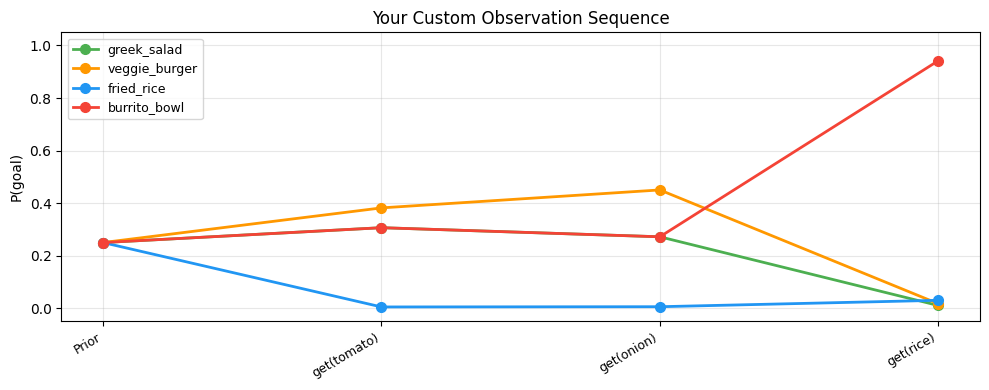

Final: {'greek_salad': 0.011, 'veggie_burger': 0.017, 'fried_rice': 0.03, 'burrito_bowl': 0.942}


In [8]:
# Try your own observation sequence!
# Available actions: get(tomato), get(olives), get(cucumber), get(onion),
#   get(feta_cheese), get(hamburger_bun), get(lettuce), get(frozen_patty),
#   get(rice), get(soy_sauce), get(frozen_peas), get(frozen_carrots),
#   get(black_beans), get(cotija_cheese), checkout()

my_observations = [
    Observation('act', 'get(tomato)'),
    Observation('act', 'get(onion)'),
    Observation('act', 'get(rice)'),  # This disambiguates toward burrito_bowl!
]

result = run_inference_loop(my_observations)
traj = result['posterior_trajectory']

fig, ax = plt.subplots(figsize=(10, 4))
for i, goal in enumerate(GOALS):
    ax.plot(range(len(traj)), [t[i] for t in traj],
            'o-', color=COLORS[i], linewidth=2, label=goal, markersize=7)
ax.set_xticks(range(len(traj)))
ax.set_xticklabels(['Prior'] + [o.value for o in my_observations], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('P(goal)'); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9); ax.grid(alpha=0.3)
ax.set_title('Your Custom Observation Sequence')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'custom_observations.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Final: {dict(zip(GOALS, np.round(result['posterior'], 3)))}")

---

## 5. Overcooked-AI: Multi-Step Recipes <a name="overcooked"></a>

Now we scale up to a richer domain: **Overcooked-AI**, a cooperative cooking game. Each recipe involves a multi-step sequence:

1. **Pick up** each ingredient from its dispenser
2. **Add to pot** each ingredient
3. **Start cooking** the soup
4. **Pick up a dish** from the dish dispenser
5. **Pick up the soup** from the pot onto the dish
6. **Serve** at the serving window

We define 4 five-ingredient soups with overlapping ingredient sets:

| Recipe | Ingredients |
|--------|------------|
| Greek Salad Soup | tomato, olive, cucumber, onion, feta_cheese |
| Veggie Burger Soup | hamburger_bun, tomato, onion, cucumber, frozen_carrots |
| Fried Rice Soup | rice, onion, soy_sauce, frozen_peas, frozen_carrots |
| Burrito Bowl Soup | rice, olive, feta_cheese, onion, tomato |

In [9]:
# ── Overcooked Goal Model ──

def recipe_to_goal_name(ingredients: List[str]) -> str:
    """Convert ingredient list to a readable goal name.
    E.g. ['onion','onion','onion'] -> '3_onion_soup'
    """
    counts = Counter(ingredients)
    parts = []
    for ing in sorted(counts.keys()):
        c = counts[ing]
        parts.append(f"{c}_{ing}" if c > 1 else ing)
    return "_".join(parts) + "_soup"


def build_plan_for_recipe(ingredients: List[str]) -> Dict[str, List[str]]:
    """Build a plan DAG for an Overcooked recipe.

    Dependency structure:
    pick_up(X)_i → add_to_pot(X)_i → start_cooking → pick_up_soup → serve_soup
                                     pick_up_dish ↗
    """
    counts = Counter(ingredients)
    plan = {}
    add_to_pot_actions = []

    idx = 0
    for ing in sorted(counts.keys()):
        for i in range(counts[ing]):
            idx += 1
            pick_action = f"pick_up({ing})_{idx}"
            pot_action = f"add_to_pot({ing})_{idx}"
            plan[pick_action] = []            # no dependencies
            plan[pot_action] = [pick_action]  # must pick up first
            add_to_pot_actions.append(pot_action)

    plan["start_cooking"] = add_to_pot_actions[:]  # all ingredients in pot
    plan["pick_up_dish"] = []                       # independent
    plan["pick_up_soup"] = ["start_cooking", "pick_up_dish"]
    plan["serve_soup"] = ["pick_up_soup"]
    return plan


def build_overcooked_goals(all_orders):
    """Build goals, plans, and uniform prior from a list of ingredient lists."""
    goals, plans = [], {}
    for ingredients in all_orders:
        name = recipe_to_goal_name(ingredients)
        if name not in plans:
            goals.append(name)
            plans[name] = build_plan_for_recipe(ingredients)
    prior = np.ones(len(goals)) / len(goals)
    return goals, plans, prior


# Overcooked action space (symbolic)
BASE_INGREDIENTS = [
    'onion', 'tomato', 'cucumber', 'rice', 'olive',
    'feta_cheese', 'hamburger_bun', 'soy_sauce', 'frozen_peas', 'frozen_carrots',
]

OVERCOOKED_ACTIONS = (
    [f'pick_up({ing})' for ing in BASE_INGREDIENTS]
    + [f'add_to_pot({ing})' for ing in BASE_INGREDIENTS]
    + ['start_cooking', 'pick_up_dish', 'pick_up_soup', 'serve_soup', 'wait']
)

# Define our 4 five-ingredient recipes
RECIPE_NAMES = ['Greek Salad', 'Veggie Burger', 'Fried Rice', 'Burrito Bowl']
RECIPE_INGREDIENTS = [
    ['tomato', 'olive', 'cucumber', 'onion', 'feta_cheese'],
    ['hamburger_bun', 'tomato', 'onion', 'cucumber', 'frozen_carrots'],
    ['rice', 'onion', 'soy_sauce', 'frozen_peas', 'frozen_carrots'],
    ['rice', 'olive', 'feta_cheese', 'onion', 'tomato'],
]

oc_goals, oc_plans, oc_prior = build_overcooked_goals(RECIPE_INGREDIENTS)

print(f"Overcooked goals: {oc_goals}")
print(f"\nExample plan for Fried Rice ({oc_goals[2]}):")
for action, deps in oc_plans[oc_goals[2]].items():
    dep_str = ', '.join(deps) if deps else '(none)'
    print(f"  {action:30s} depends on: {dep_str}")

Overcooked goals: ['cucumber_feta_cheese_olive_onion_tomato_soup', 'cucumber_frozen_carrots_hamburger_bun_onion_tomato_soup', 'frozen_carrots_frozen_peas_onion_rice_soy_sauce_soup', 'feta_cheese_olive_onion_rice_tomato_soup']

Example plan for Fried Rice (frozen_carrots_frozen_peas_onion_rice_soy_sauce_soup):
  pick_up(frozen_carrots)_1      depends on: (none)
  add_to_pot(frozen_carrots)_1   depends on: pick_up(frozen_carrots)_1
  pick_up(frozen_peas)_2         depends on: (none)
  add_to_pot(frozen_peas)_2      depends on: pick_up(frozen_peas)_2
  pick_up(onion)_3               depends on: (none)
  add_to_pot(onion)_3            depends on: pick_up(onion)_3
  pick_up(rice)_4                depends on: (none)
  add_to_pot(rice)_4             depends on: pick_up(rice)_4
  pick_up(soy_sauce)_5           depends on: (none)
  add_to_pot(soy_sauce)_5        depends on: pick_up(soy_sauce)_5
  start_cooking                  depends on: add_to_pot(frozen_carrots)_1, add_to_pot(frozen_peas)_2,

### Running Overcooked Inference

The Overcooked plans use **numbered** actions (e.g., `pick_up(onion)_1`) to handle duplicate ingredients, while observations use **unnumbered** names (e.g., `pick_up(onion)`). We need a matching function to bridge this gap:

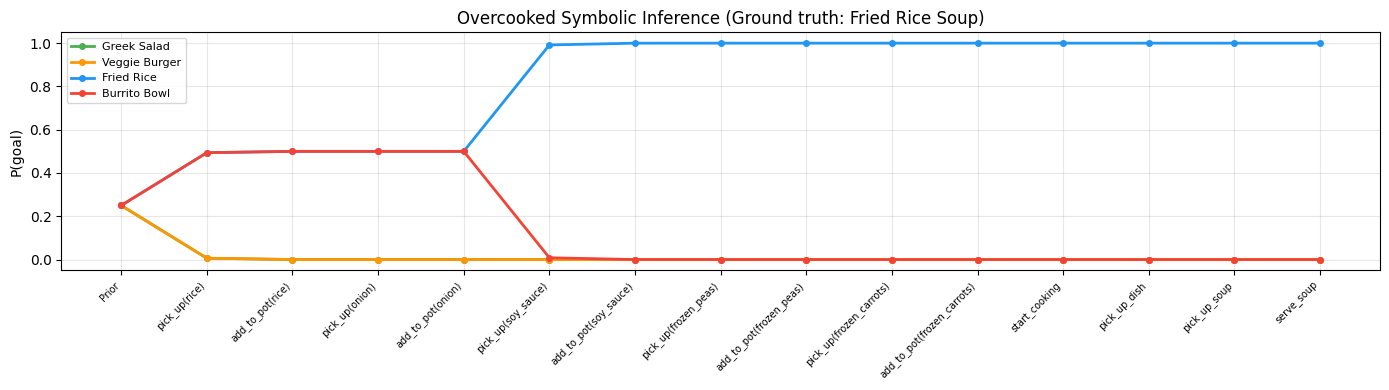

Final: {'Greek Salad': 0.0, 'Veggie Burger': 0.0, 'Fried Rice': 1.0, 'Burrito Bowl': 0.0}


In [10]:
@dataclass(frozen=True)
class OvercookedObservation:
    """Observation from the Overcooked game."""
    kind: str           # 'act'
    value: str          # e.g. 'pick_up(onion)'
    player_index: int   # which player
    timestep: int       # when it happened


def _match_action_to_plan(action: str, plan: Dict[str, List[str]], state: Set[str]):
    """Find the first matching numbered plan action for an unnumbered observation."""
    for plan_action in plan:
        if plan_action in state:
            continue
        base = plan_action.rsplit('_', 1)[0] if '_' in plan_action else plan_action
        if base == action or plan_action == action:
            return plan_action
    return None


def run_overcooked_inference(
    observations: List[OvercookedObservation],
    goals: List[str],
    plans: Dict[str, Dict[str, List[str]]],
    prior: np.ndarray,
    act_noise: float = 0.05,
) -> Dict:
    """Run Bayesian inference over Overcooked observations."""
    posterior = prior.copy()
    states = {goal: set() for goal in goals}
    posterior_trajectory = [posterior.copy()]

    for obs in observations:
        likelihood = np.zeros(len(goals))
        for i, goal in enumerate(goals):
            plan = plans[goal]
            state = states[goal]
            planned = get_planned_actions(state, plan)
            matched = _match_action_to_plan(obs.value, plan, state)

            if matched and matched in planned:
                likelihood[i] = (1.0 - act_noise) / len(planned)
                likelihood[i] += act_noise / max(len(OVERCOOKED_ACTIONS), 1)
            else:
                likelihood[i] = act_noise / max(len(OVERCOOKED_ACTIONS), 1)

        likelihood = np.maximum(likelihood, 1e-300)
        posterior = posterior_update(posterior, likelihood)
        posterior_trajectory.append(posterior.copy())

        # Update per-goal states
        for goal in goals:
            matched = _match_action_to_plan(obs.value, plans[goal], states[goal])
            if matched:
                states[goal].add(matched)

    return {'posterior': posterior, 'posterior_trajectory': posterior_trajectory,
            'observations': observations, 'goals': goals}


# Simulate Player 1 making Fried Rice Soup
ingredient_order = ['rice', 'onion', 'soy_sauce', 'frozen_peas', 'frozen_carrots']
oc_observations = []
t = 0
for ing in ingredient_order:
    oc_observations.append(OvercookedObservation('act', f'pick_up({ing})', 0, t)); t += 1
    oc_observations.append(OvercookedObservation('act', f'add_to_pot({ing})', 0, t)); t += 1
for a in ['start_cooking', 'pick_up_dish', 'pick_up_soup', 'serve_soup']:
    oc_observations.append(OvercookedObservation('act', a, 0, t)); t += 1

oc_result = run_overcooked_inference(oc_observations, oc_goals, oc_plans, oc_prior)
oc_traj = oc_result['posterior_trajectory']

# Plot
fig, ax = plt.subplots(figsize=(14, 4))
for i, rname in enumerate(RECIPE_NAMES):
    ax.plot(range(len(oc_traj)), [t[i] for t in oc_traj],
            'o-', color=COLORS[i], linewidth=2, label=rname, markersize=4)
ax.set_xticks(range(len(oc_traj)))
ax.set_xticklabels(['Prior'] + [o.value for o in oc_observations], rotation=45, ha='right', fontsize=7)
ax.set_ylabel('P(goal)'); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_title('Overcooked Symbolic Inference (Ground truth: Fried Rice Soup)')
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'overcooked_symbolic.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"Final: {dict(zip(RECIPE_NAMES, np.round(oc_result['posterior'], 3)))}")

### Observations

The Overcooked domain has more observations (14 vs 6) because each ingredient goes through two steps (pick up + add to pot). The posterior converges more gradually but reaches the same conclusion.

Notice the interesting dynamics:
- **Picking up rice** narrows it to Fried Rice and Burrito Bowl (both use rice)
- **Adding rice to pot** and **picking up onion** don't disambiguate further (both still use onion)
- **Picking up soy_sauce** is the key discriminator — only Fried Rice Soup uses it

---

## 6. CLIP Vision-Based Inference <a name="clip"></a>

So far we've assumed access to **ground-truth symbolic actions** like `pick_up(rice)`. In practice, an observer watching the game would only see **raw pixel frames**. Can we infer goals from vision alone?

### The Action Marginalization Approach

We use **CLIP** (Contrastive Language-Image Pre-training) as a frame-level action classifier. The graphical model is:

$$g \rightarrow a_t \rightarrow I_t$$

Where $g$ is the goal, $a_t$ is the action, and $I_t$ is the image frame. Since we don't observe $a_t$ directly, we **marginalize** over all possible actions:

$$P(I_t \mid g) = \sum_a P(a \mid I_t) \cdot P(a \mid g, s_{t-1})$$

- $P(a \mid I_t)$ comes from **CLIP**: cosine similarity between the image embedding and action text prompts, passed through a temperature-scaled softmax
- $P(a \mid g, s_{t-1})$ comes from the **plan model** (same as the symbolic case)

This is a dot product between two probability vectors — one from vision, one from planning.

### Why This Works

If CLIP perfectly identifies the action ($P(a|I_t) = 1$ for the true action), the marginalization reduces to the symbolic likelihood:

$$P(I_t \mid g) = P(a_{\text{true}} \mid g, s_{t-1})$$

If CLIP is uncertain, the marginalization gracefully handles the uncertainty by weighting all possible actions.

### Implementation

We define text prompts for each action and use CLIP to compute similarities:

In [11]:
# ── CLIP Action Classifier ──

import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
from PIL import Image


# Human-readable names for CLIP prompts
INGREDIENT_DISPLAY = {
    'onion': 'onion', 'tomato': 'tomato', 'cucumber': 'cucumber',
    'rice': 'rice', 'olive': 'olive', 'feta_cheese': 'feta cheese',
    'hamburger_bun': 'hamburger bun', 'soy_sauce': 'soy sauce',
    'frozen_peas': 'frozen peas', 'frozen_carrots': 'frozen carrots',
}


def build_action_prompts():
    """Build text prompts for CLIP action classification.

    Returns (prompts, action_keys) where each prompt describes an action
    in natural language for CLIP to match against image frames.
    """
    prompts, action_keys = [], []

    for ing in BASE_INGREDIENTS:
        display = INGREDIENT_DISPLAY[ing]
        prompts.append(f"The blue hat chef is picking up {display} from the {display} dispenser")
        action_keys.append(f"pick_up({ing})")
        prompts.append(f"The blue hat chef is adding {display} to the cooking pot")
        action_keys.append(f"add_to_pot({ing})")

    # Generic non-ingredient actions
    for prompt, key in [
        ("The blue hat chef is walking in the kitchen", "moving"),
        ("The blue hat chef is standing still and waiting", "idle"),
        ("The blue hat chef is starting to cook the soup in the pot", "start_cooking"),
        ("The blue hat chef is picking up a dish from the dish dispenser", "pick_up_dish"),
        ("The blue hat chef is picking up the cooked soup from the pot", "pick_up_soup"),
        ("The blue hat chef is serving the soup at the serving window", "serve_soup"),
    ]:
        prompts.append(prompt)
        action_keys.append(key)

    return prompts, action_keys


# All CLIP action keys (matches what the classifier produces)
CLIP_ACTION_KEYS = (
    [f'pick_up({ing})' for ing in BASE_INGREDIENTS]
    + [f'add_to_pot({ing})' for ing in BASE_INGREDIENTS]
    + ['moving', 'idle', 'start_cooking', 'pick_up_dish', 'pick_up_soup', 'serve_soup']
)

print(f"Number of action prompts: {len(build_action_prompts()[0])}")
print(f"\nSample prompts:")
prompts, keys = build_action_prompts()
for p, k in list(zip(prompts, keys))[:4]:
    print(f"  [{k:20s}] {p}")

Number of action prompts: 26

Sample prompts:
  [pick_up(onion)      ] The blue hat chef is picking up onion from the onion dispenser
  [add_to_pot(onion)   ] The blue hat chef is adding onion to the cooking pot
  [pick_up(tomato)     ] The blue hat chef is picking up tomato from the tomato dispenser
  [add_to_pot(tomato)  ] The blue hat chef is adding tomato to the cooking pot


In [12]:
class CLIPActionClassifier:
    """Frame-level action classifier using CLIP similarity scoring.

    For each frame, produces P(action | frame) over all defined actions.
    """

    def __init__(self, model_name='openai/clip-vit-base-patch32',
                 temperature=0.5, device=None):
        if device is None:
            device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.device = device
        self.temperature = temperature

        print(f"Loading CLIP model: {model_name} on {device}...")
        self.model = CLIPModel.from_pretrained(model_name).to(device)
        self.processor = CLIPProcessor.from_pretrained(model_name)
        self.model.eval()
        print("CLIP model loaded.")

        # Build and pre-encode text prompts (done once)
        self.prompts, self.action_keys = build_action_prompts()
        self._encode_text_prompts()

        # Build action-to-index mapping
        self.action_to_indices = {}
        for idx, key in enumerate(self.action_keys):
            self.action_to_indices.setdefault(key, []).append(idx)

    def _encode_text_prompts(self):
        """Pre-encode all text prompts."""
        inputs = self.processor(
            text=self.prompts, return_tensors='pt', padding=True, truncation=True
        ).to(self.device)
        with torch.no_grad():
            raw = self.model.get_text_features(**inputs)
            self.text_embeddings = F.normalize(raw, dim=-1)

    def classify_frame(self, image: Image.Image) -> Dict[str, float]:
        """Classify a single frame into P(action | frame)."""
        inputs = self.processor(images=image, return_tensors='pt').to(self.device)
        with torch.no_grad():
            raw = self.model.get_image_features(**inputs)
            image_embedding = F.normalize(raw, dim=-1)

        similarities = (image_embedding @ self.text_embeddings.T).squeeze(0)
        logits = similarities / self.temperature
        probs = F.softmax(logits, dim=0).cpu().numpy()

        # Aggregate: sum probs for duplicate action keys
        result = {}
        for key in set(self.action_keys):
            indices = self.action_to_indices[key]
            result[key] = float(sum(probs[i] for i in indices))
        return result


print("CLIPActionClassifier defined. Will be instantiated when needed.")

CLIPActionClassifier defined. Will be instantiated when needed.


### The Plan-Based Action Distribution

For the marginalization, we also need $P(a \mid g, s)$ — the plan-based probability of each action given a goal and state. This is the same as the symbolic likelihood, but expressed over the CLIP action space:

In [13]:
def get_planned_actions_for_clip(state: Set[str], plan: Dict[str, List[str]]) -> List[str]:
    """Get currently planned actions, returning base (unnumbered) action names."""
    planned = []
    for act in plan:
        if act in state:
            continue
        if all(dep in state for dep in plan[act]):
            parts = act.rsplit('_', 1)
            base = parts[0] if len(parts) == 2 and parts[1].isdigit() else act
            if base not in planned:
                planned.append(base)
    return sorted(planned) if planned else ['wait']


def plan_action_distribution(
    state: Set[str], plan: Dict[str, List[str]], act_noise: float = 0.05
) -> Dict[str, float]:
    """Compute P(a | goal, state) over CLIP action keys."""
    planned = get_planned_actions_for_clip(state, plan)
    n_actions = len(CLIP_ACTION_KEYS)
    dist = {}
    for action_key in CLIP_ACTION_KEYS:
        if action_key in planned:
            dist[action_key] = (1.0 - act_noise) / len(planned) + act_noise / n_actions
        else:
            dist[action_key] = act_noise / n_actions
    return dist


def clip_action_marginalization_likelihood(
    action_probs: Dict[str, float],
    goals: List[str],
    plans: Dict[str, Dict[str, List[str]]],
    states: Dict[str, Set[str]],
    act_noise: float = 0.05,
) -> np.ndarray:
    """Compute P(frame | goal) via action marginalization.

    P(I_t | g, s) = sum_a P(a | I_t) * P(a | g, s)

    This is a dot product between the CLIP action distribution
    and the plan-based action distribution for each goal.
    """
    likelihoods = np.zeros(len(goals))
    for i, goal in enumerate(goals):
        plan_dist = plan_action_distribution(states[goal], plans[goal], act_noise)
        dot = sum(
            action_probs.get(key, 0.0) * plan_dist[key]
            for key in CLIP_ACTION_KEYS
        )
        likelihoods[i] = dot
    return np.maximum(likelihoods, 1e-300)


# Demonstrate the marginalization with a hypothetical CLIP output
# Suppose CLIP thinks the frame shows pick_up(rice) with 60% confidence
fake_clip_output = {k: 0.02 for k in CLIP_ACTION_KEYS}
fake_clip_output['pick_up(rice)'] = 0.60
fake_clip_output['pick_up(onion)'] = 0.10  # some confusion

# Renormalize
total = sum(fake_clip_output.values())
fake_clip_output = {k: v/total for k, v in fake_clip_output.items()}

empty_states = {g: set() for g in oc_goals}
likelihoods = clip_action_marginalization_likelihood(
    fake_clip_output, oc_goals, oc_plans, empty_states
)

print("Hypothetical CLIP output: mostly pick_up(rice)")
print("\nMarginalized likelihoods P(frame | goal):")
for g, l in zip(RECIPE_NAMES, likelihoods):
    print(f"  {g:20s}: {l:.4f}")
print(f"\nGoals with rice get higher likelihood (as expected).")

Hypothetical CLIP output: mostly pick_up(rice)

Marginalized likelihoods P(frame | goal):
  Greek Salad         : 0.0288
  Veggie Burger       : 0.0288
  Fried Rice          : 0.1066
  Burrito Bowl        : 0.1066

Goals with rice get higher likelihood (as expected).


### Putting It Together: CLIP Inference Engine

Now we combine CLIP classification + action marginalization + Bayesian updating into a complete inference engine. Note: loading CLIP requires downloading the model (~600 MB), which takes a moment on Colab.

**If you don't have a GPU or want to skip the CLIP model download**, you can jump to Section 7 (Dummy CLIP) which simulates the same behavior without needing the actual model.

In [14]:
class CLIPRecipeInference:
    """End-to-end CLIP-based recipe inference engine.

    Maintains a Bayesian posterior over recipes, updated frame-by-frame.
    """

    def __init__(self, recipe_names, plans, model_name='openai/clip-vit-base-patch32',
                 temperature=0.5, act_noise=0.05, device=None):
        self.recipe_names = recipe_names
        self.plans = plans
        self.n_recipes = len(recipe_names)
        self.act_noise = act_noise
        self.classifier = CLIPActionClassifier(model_name, temperature, device)

        # Bayesian state
        self.posterior = np.ones(self.n_recipes) / self.n_recipes
        self.posterior_history = [self.posterior.copy()]
        self.states = {g: set() for g in self.recipe_names}

    def observe_action(self, action_str):
        """Update plan states after a symbolic action is observed."""
        if action_str is None:
            return
        for goal in self.recipe_names:
            plan = self.plans[goal]
            for plan_act in plan:
                if plan_act in self.states[goal]:
                    continue
                base = plan_act.rsplit('_', 1)[0] if '_' in plan_act else plan_act
                if base == action_str or plan_act == action_str:
                    self.states[goal].add(plan_act)
                    break

    def observe_frame(self, image):
        """Process one frame and return updated posterior."""
        action_probs = self.classifier.classify_frame(image)
        likelihood = clip_action_marginalization_likelihood(
            action_probs, self.recipe_names, self.plans,
            self.states, self.act_noise
        )
        unnormalized = self.posterior * likelihood
        total = unnormalized.sum()
        self.posterior = unnormalized / total if total > 0 else np.ones(self.n_recipes) / self.n_recipes
        self.posterior_history.append(self.posterior.copy())
        return self.posterior.copy()

print("CLIPRecipeInference defined.")

CLIPRecipeInference defined.


---

## 7. Qwen3-VL: Direct VLM Inference <a name="qwen"></a>

Instead of the two-step pipeline (CLIP classifies actions → marginalize over plan), we can use a **Vision Language Model (VLM)** to directly estimate $P(\text{recipe} \mid \text{frames})$ end-to-end.

**Qwen3-VL** is a multimodal model that takes both images and text as input. We show it a sequence of game frames and ask it to estimate the probability of each recipe directly. This skips the action-classification bottleneck entirely — the VLM reasons about the visual scene holistically.

### Key Differences from CLIP

| | CLIP (§6) | Qwen3-VL (§7) |
|--|-----------|---------------|
| **Architecture** | Contrastive image-text encoder | Autoregressive vision-language model |
| **Approach** | Classify action per frame → marginalize | Directly estimate recipe probabilities |
| **Update rule** | Bayesian (multiply likelihoods) | Direct posterior replacement |
| **Context** | Single frame at a time | Multiple frames in one query |
| **When queried** | Every frame | Only at key events (e.g., `add_to_pot`) |

### The Prompt

We provide Qwen3-VL with a detailed description of the kitchen layout (which dispensers are on which wall) and the four candidate recipes, then show it the last several game frames and ask it to output probability estimates:

In [15]:
import re

QWEN_PROMPT = """\
You are watching a cooperative cooking game from a top-down view. \
Two chefs (blue hat and green hat) are in a kitchen with ingredient dispensers on the walls. \
The blue-hat chef (Player 1) is trying to make one of four possible soups. \
Each soup requires exactly 5 ingredients picked up from dispensers and added to a pot.

The four candidate goals and their recipes are:

Recipe A - "Greek Salad Soup":
  Ingredients: tomato, olive, cucumber, onion, feta cheese
  (Player picks from: Tomato dispenser on top wall, Olive dispenser on left wall, \
Cucumber dispenser on top wall, Onion dispenser on top wall, Feta Cheese dispenser on left wall)

Recipe B - "Veggie Burger Soup":
  Ingredients: hamburger bun, tomato, onion, cucumber, frozen carrots
  (Player picks from: Hamburger Bun dispenser on right wall, Tomato on top wall, \
Onion on top wall, Cucumber on top wall, Frozen Carrots on bottom wall)

Recipe C - "Fried Rice Soup":
  Ingredients: rice, onion, soy sauce, frozen peas, frozen carrots
  (Player picks from: Rice dispenser on top wall, Onion on top wall, \
Soy Sauce on right wall, Frozen Peas on bottom wall, Frozen Carrots on bottom wall)

Recipe D - "Burrito Bowl Soup":
  Ingredients: rice, olive, feta cheese, onion, tomato
  (Player picks from: Rice on top wall, Olive on left wall, \
Feta Cheese on left wall, Onion on top wall, Tomato on top wall)

Kitchen layout:
- Top wall (left to right): Onion (white bulb), Tomato (red), Cucumber (green), Rice (white grains)
- Left wall (top to bottom): Olive (purple/dark), Feta Cheese (yellow block)
- Right wall (top to bottom): Hamburger Bun (brown), Soy Sauce (dark bottle)
- Bottom wall: Dish dispenser, Frozen Peas (green bag), Frozen Carrots (orange bag), Serving window
- Top right corner: Cooking pot

I'm showing you the last several frames of the game in chronological order. \
Observe which dispensers the blue-hat player visits, which ingredients they pick up, \
and which items they add to the pot. Based on these observations, \
estimate the probability that they are making each recipe.

Answer ONLY in this exact format (numbers must sum to 1.0):
Recipe A: <probability>
Recipe B: <probability>
Recipe C: <probability>
Recipe D: <probability>"""


def load_qwen_vl_model(model_name="Qwen/Qwen3-VL-4B-Instruct"):
    """Load Qwen3-VL model and processor."""
    from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

    print(f"Loading Qwen3-VL model: {model_name} ...")
    model = Qwen3VLForConditionalGeneration.from_pretrained(
        model_name, torch_dtype=torch.float16, device_map="auto",
    )
    processor = AutoProcessor.from_pretrained(model_name)
    print("Model loaded.")
    return model, processor


def query_qwen_vl(model, processor, frame_images, prompt=QWEN_PROMPT):
    """Query Qwen3-VL with a list of PIL images and return raw text response."""
    content = []
    for img in frame_images:
        content.append({"type": "image", "image": img})
    content.append({"type": "text", "text": prompt})

    messages = [{"role": "user", "content": content}]

    inputs = processor.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device)

    with torch.no_grad():
        output_ids = model.generate(**inputs, max_new_tokens=256)

    generated_ids = [
        out[len(inp):] for inp, out in zip(inputs.input_ids, output_ids)
    ]
    response = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response


def parse_qwen_response(response_text, n_recipes=4):
    """Parse probability response from Qwen3-VL.

    Expected format:
      Recipe A: 0.3
      Recipe B: 0.2
      Recipe C: 0.4
      Recipe D: 0.1
    """
    labels = [chr(ord("A") + i) for i in range(n_recipes)]
    probs = []
    for label in labels:
        pattern = rf"Recipe {label}\s*[:=]\s*([0-9]*\.?[0-9]+)"
        match = re.search(pattern, response_text, re.IGNORECASE)
        if match:
            probs.append(float(match.group(1)))
        else:
            return None
    total = sum(probs)
    if total <= 0:
        return None
    return [p / total for p in probs]


print("Qwen3-VL helpers defined.")
print(f"Prompt length: {len(QWEN_PROMPT)} characters")

Qwen3-VL helpers defined.
Prompt length: 2207 characters


### Qwen3-VL Inference Engine

Unlike the CLIP approach which performs Bayesian updates frame-by-frame, the VLM approach:
1. Accumulates frames over time
2. At each key event (e.g., adding an ingredient to the pot), sends the **last ~20 frames** to the VLM
3. The VLM directly outputs a full probability distribution over recipes
4. This **replaces** the posterior (no multiplicative Bayesian update)

This is simpler but requires a more capable model — the VLM must understand the visual scene, track which ingredients have been used, and reason about which recipe is being prepared.

**Note:** Running this cell requires a GPU with ~8GB VRAM for the 4B model. If unavailable, the cell will print a message and skip.

In [16]:
class QwenRecipeInference:
    """End-to-end Qwen3-VL-based recipe inference engine.

    Unlike CLIP (which does per-frame Bayesian updates), this queries the VLM
    at key events with accumulated frames and uses the VLM's output directly
    as the posterior.
    """

    def __init__(self, recipe_names, model_name='Qwen/Qwen3-VL-4B-Instruct'):
        self.recipe_names = recipe_names
        self.n_recipes = len(recipe_names)
        self.model, self.processor = load_qwen_vl_model(model_name)
        self.posterior = np.ones(self.n_recipes) / self.n_recipes
        self.posterior_history = [self.posterior.copy()]
        self.frame_buffer = []
        self.query_log = []

    def add_frame(self, image):
        """Add a frame to the buffer."""
        self.frame_buffer.append(image)

    def query_and_update(self):
        """Query Qwen3-VL with accumulated frames and update posterior."""
        if not self.frame_buffer:
            return self.posterior.copy()

        # Downsample to last 20 frames
        frames = self.frame_buffer[-20:]
        response = query_qwen_vl(self.model, self.processor, frames)
        probs = parse_qwen_response(response)

        if probs is not None:
            self.posterior = np.array(probs)
        self.posterior_history.append(self.posterior.copy())
        self.query_log.append({
            'n_frames': len(frames),
            'response': response,
            'parsed': probs,
        })
        return self.posterior.copy()


# Demo: test the parser with a sample response
sample_response = "Recipe A: 0.1\nRecipe B: 0.05\nRecipe C: 0.8\nRecipe D: 0.05"
parsed = parse_qwen_response(sample_response)
print(f"Sample VLM response parsing:")
print(f"  Input:  {sample_response}")
print(f"  Parsed: {dict(zip(RECIPE_NAMES, parsed))}")
print(f"\nQwenRecipeInference defined.")
print("To run Qwen inference, you need a GPU. The model will be loaded on first use.")

Sample VLM response parsing:
  Input:  Recipe A: 0.1
Recipe B: 0.05
Recipe C: 0.8
Recipe D: 0.05
  Parsed: {'Greek Salad': 0.1, 'Veggie Burger': 0.05, 'Fried Rice': 0.8, 'Burrito Bowl': 0.05}

QwenRecipeInference defined.
To run Qwen inference, you need a GPU. The model will be loaded on first use.


---

## 8. Effect of Classifier Accuracy (Dummy CLIP) <a name="dummy-clip"></a>

To understand the relationship between classifier accuracy and inference quality, we replace the real CLIP model with a **synthetic "perfect" classifier**. This dummy classifier:

- Assigns probability $p_{\text{diag}}$ to the **true action**
- Spreads the remaining $(1 - p_{\text{diag}})$ uniformly across all other actions

By sweeping $p_{\text{diag}}$ from 0.5 (poor) to 0.95 (excellent), we can see the upper bound on inference quality for the action-marginalization approach.

In [17]:
class DummyCLIPRecipeInference:
    """Simulated ideal CLIP classifier for upper-bound experiments.

    Uses hardcoded action probabilities instead of actual vision:
    true action gets diag_prob, rest get uniform.
    """

    def __init__(self, recipe_names, plans, diag_prob=0.8, act_noise=0.05):
        self.recipe_names = recipe_names
        self.plans = plans
        self.n_recipes = len(recipe_names)
        self.diag_prob = diag_prob
        self.act_noise = act_noise

        self.posterior = np.ones(self.n_recipes) / self.n_recipes
        self.posterior_history = [self.posterior.copy()]
        self.states = {g: set() for g in self.recipe_names}
        self._current_action = None

    def set_current_action(self, action_str):
        """Set the true action for the current frame."""
        self._current_action = action_str

    def _build_dummy_action_probs(self):
        """Build P(action | frame) with diag_prob on the true action."""
        n = len(CLIP_ACTION_KEYS)
        off_diag = (1.0 - self.diag_prob) / (n - 1)
        probs = {key: off_diag for key in CLIP_ACTION_KEYS}

        true_action = self._current_action
        if true_action is None or true_action not in CLIP_ACTION_KEYS:
            probs['moving'] = self.diag_prob  # default to "moving"
        else:
            probs[true_action] = self.diag_prob
        return probs

    def observe_action(self, action_str):
        """Update per-goal plan states."""
        if action_str is None:
            return
        for goal in self.recipe_names:
            plan = self.plans[goal]
            for plan_act in plan:
                if plan_act in self.states[goal]:
                    continue
                base = plan_act.rsplit('_', 1)[0] if '_' in plan_act else plan_act
                if base == action_str or plan_act == action_str:
                    self.states[goal].add(plan_act)
                    break

    def observe_frame(self, image=None):
        """Process one frame (image ignored; uses hardcoded probs)."""
        action_probs = self._build_dummy_action_probs()
        likelihood = clip_action_marginalization_likelihood(
            action_probs, self.recipe_names, self.plans,
            self.states, self.act_noise
        )
        unnormalized = self.posterior * likelihood
        total = unnormalized.sum()
        self.posterior = unnormalized / total if total > 0 else np.ones(self.n_recipes) / self.n_recipes
        self.posterior_history.append(self.posterior.copy())
        return self.posterior.copy()


print("DummyCLIPRecipeInference defined.")

DummyCLIPRecipeInference defined.


### Accuracy Sweep

Let's sweep across three accuracy levels and compare convergence behavior:

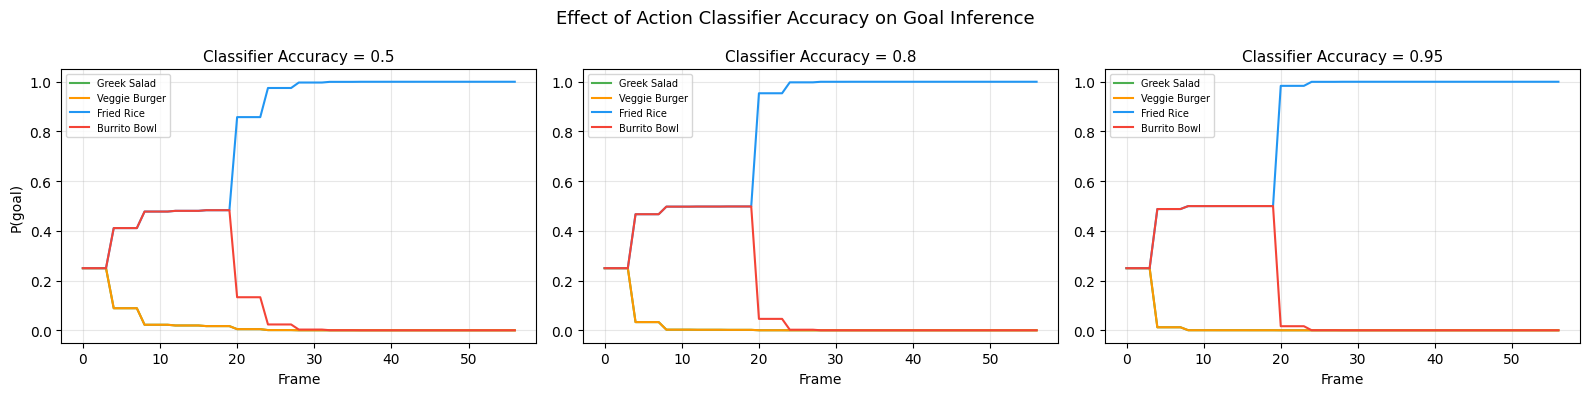

In [18]:
# Build the action sequence for fried rice
action_seq = []
for ing in ingredient_order:
    action_seq += [f'pick_up({ing})', f'add_to_pot({ing})']
action_seq += ['start_cooking', 'pick_up_dish', 'pick_up_soup', 'serve_soup']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
accuracy_levels = [0.5, 0.8, 0.95]

for ax, diag_p in zip(axes, accuracy_levels):
    engine = DummyCLIPRecipeInference(
        recipe_names=oc_goals, plans=oc_plans, diag_prob=diag_p
    )

    for a in action_seq:
        # Simulate 3 "moving" frames between each action
        for _ in range(3):
            engine.set_current_action(None)
            engine.observe_frame()
        # Then the actual action frame
        engine.set_current_action(a)
        engine.observe_frame()
        engine.observe_action(a)

    for i, rn in enumerate(RECIPE_NAMES):
        ax.plot([h[i] for h in engine.posterior_history],
                color=COLORS[i], linewidth=1.5, label=rn)
    ax.set_title(f'Classifier Accuracy = {diag_p}', fontsize=11)
    ax.set_xlabel('Frame')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

axes[0].set_ylabel('P(goal)')
fig.suptitle('Effect of Action Classifier Accuracy on Goal Inference', fontsize=13)
fig.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'dummy_clip_accuracy_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()

### Analysis

Even at 0.5 accuracy (essentially coin-flip level), Bayesian updating still eventually converges to the correct goal — it just takes more frames. This demonstrates the **robustness of Bayesian inference**: weak evidence accumulates over time. Better vision models simply mean faster convergence.

---

## 9. Summary & Extensions <a name="summary"></a>

### What We Covered

| Method | Input | Key Equation | Strengths | Limitations |
|--------|-------|-------------|-----------|-------------|
| **Symbolic** (§4–5) | Ground-truth actions | $P(a_t \mid g, s) = \frac{1-\varepsilon}{\|\text{planned}\|} + \frac{\varepsilon}{\|\text{possible}\|}$ | Fast convergence, no GPU needed | Requires perfect action recognition |
| **CLIP** (§6) | Raw game frames | $P(I_t \mid g) = \sum_a P(a \mid I_t) \cdot P(a \mid g, s)$ | Works from vision, no labels needed | Limited by CLIP's accuracy on game sprites |
| **Qwen3-VL** (§7) | Raw game frames | Direct $P(g \mid I_{1:t})$ estimation | End-to-end, no action bottleneck, richer reasoning | Requires GPU, slower per query, less interpretable |
| **Dummy CLIP** (§8) | Simulated classifier | Same as CLIP, controlled accuracy | Shows upper bounds, fast experiments | Not a real vision system |

All Bayesian methods share the same **recursive update**:

$$P(g \mid \text{obs}_{1:t}) \propto P(\text{obs}_t \mid g) \cdot P(g \mid \text{obs}_{1:t-1})$$

The Qwen3-VL approach skips this entirely — the VLM directly outputs the full posterior given the visual context.

### Key Takeaways

1. **Bayesian updating is powerful**: Even weak evidence accumulates over time to identify the correct goal.
2. **Plan-based likelihoods exploit structure**: Knowing what actions are *expected* under each goal creates strong discriminative signals.
3. **Action marginalization bridges vision and planning**: We don't need to commit to a single action classification — integrating over all possibilities is more robust.
4. **VLMs offer a complementary approach**: Qwen3-VL can reason holistically about the visual scene without requiring an explicit action classifier or plan model.
5. **Classifier accuracy directly impacts convergence speed**: Better vision models → fewer frames needed for confident inference.

### Possible Extensions

- **Natural language instructions**: The original CLIPS framework uses LLMs to model how users communicate instructions, adding another observation modality.
- **Automatic plan generation**: Replace manually-defined plans with automated planning algorithms.
- **Multi-agent settings**: Extend to cooperative scenarios where multiple agents' goals must be inferred simultaneously.
- **Online assistance**: Use the inferred goal posterior to proactively help the user (as in the full CLIPS system).

### Reproduction

The full project code (including video rendering, Qwen-VL integration, and Overcooked game simulation) is available at the [project repository](https://github.com/ceilingFan456/CS6208_AY25-26_project). Key commands:

```bash
python render_four_goals_video.py                  # Symbolic inference video
python render_four_goals_video.py --use-clip       # CLIP inference video
python render_four_goals_video.py --use-dummy-clip # Dummy CLIP video
python render_four_goals_video.py --use-qwen       # Qwen3-VL video
python compute_clip_similarity_table.py            # CLIP similarity matrix
```

---

*CS6208 Advanced Topics in AI, AY 2025/26 — Chen Yanzhe & Huang Qiming*